<a href="https://colab.research.google.com/github/Wilson1994/DTA-2026/blob/main/homework/practice_stat_tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Статистичні тести: практикум

**Тривалість:** ~4 години · бібліотека `scipy.stats`

---

Цей практикум закріплює лекцію про p-значення та статистичну значущість. Він влаштований так:

- 🟦 **Теорія** — короткий блок перед кожним тестом: *коли* його обирати, *чому*, *як читати результат*.
- ✏️ **Завдання (код)** — ви пишете код, що проводить тест.
- 💬 **Інтерпретація** — ви **своїми словами** пояснюєте, що означає результат. Це найважливіша частина! Аналітик, який уміє порахувати p-значення, але не вміє його пояснити — це лише калькулятор.

## Як працювати
1. Читайте теоретичний блок.
2. Виконуйте завдання на код (Shift+Enter).
3. На кожне питання інтерпретації відповідайте **повним реченням людською мовою** — так, ніби пояснюєте керівнику без технічної освіти.

## Загальне правило
- `p < 0.05` → статистично значущо → відхиляємо H₀
- `p ≥ 0.05` → не значущо → не відхиляємо H₀

> 💡 Тримайте поруч шпаргалку вибору тесту з лекції. Половина завдань — про те, щоб **обрати правильний тест**.

---

## Підготовка

Запустіть цю клітинку. Ми працюємо з двома наборами даних:
- **`shop_customers.csv`** — 500 клієнтів інтернет-магазину
- **`ab_test.csv`** — результати A/B-тесту (8000 сесій)


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv("shop_customers.csv")
ab = pd.read_csv("ab_test.csv")

print("Клієнти:", df.shape)
print("A/B тест:", ab.shape)
df.head()

Клієнти: (500, 11)
A/B тест: (8000, 3)


,customer_id,gender,age,country,channel,device,spend,session_min,sat_before,sat_after,purchased
0,1001,Ч,23,Німеччина,Реклама,Desktop,997.11,22.2,6,7,Так
1,1002,Ч,38,Україна,Органіка,Desktop,510.09,19.8,5,8,Ні
2,1003,Ч,20,Україна,Соцмережі,Desktop,789.71,21.0,7,8,Ні
3,1004,Ч,40,Німеччина,Соцмережі,Desktop,1041.02,17.4,8,9,Ні
4,1005,Ч,18,Україна,Реклама,Desktop,944.34,23.5,6,7,Ні


### Опис даних `shop_customers.csv`

| Стовпець | Опис | Тип |
|---|---|---|
| `customer_id` | ID клієнта | — |
| `gender` | Стать (Ч/Ж) | категоріальний |
| `age` | Вік | числовий |
| `country` | Країна | категоріальний |
| `channel` | Канал залучення (Органіка/Реклама/Соцмережі) | категоріальний |
| `device` | Пристрій (Mobile/Desktop) | категоріальний |
| `spend` | Витрати клієнта, грн | числовий |
| `session_min` | Час на сайті, хв | числовий |
| `sat_before` | Задоволеність ДО редизайну (1-10) | числовий |
| `sat_after` | Задоволеність ПІСЛЯ редизайну (1-10) | числовий |
| `purchased` | Чи зробив покупку (Так/Ні) | категоріальний |

Спочатку завжди корисно роздивитись дані.

#### ✏️ Завдання 1 (код)

Виведіть основну статистику по числових стовпцях (підказка: метод `.describe()`).

In [ ]:
# Завдання 1:

df.describe()

,customer_id,age,spend,session_min,sat_before,sat_after
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,1250.500000,34.646000,845.016340,20.739400,6.536000,7.138000
std,144.481833,10.961615,333.460589,10.532489,1.523597,1.826919
min,1001.000000,18.000000,50.000000,1.000000,2.000000,1.000000
25%,1125.750000,26.000000,612.627500,13.100000,6.000000,6.000000
50%,1250.500000,34.000000,834.750000,20.850000,7.000000,7.000000
75%,1375.250000,41.250000,1070.395000,27.400000,8.000000,9.000000
max,1500.000000,69.000000,1952.020000,52.200000,10.000000,10.000000


#### ✏️ Завдання 2 (код)

Скільки клієнтів у кожному каналі залучення? (підказка: `.value_counts()` на стовпці `channel`)

In [ ]:
# Завдання 2:

df["channel"].value_counts()


,count
channel,
Органіка,174
Соцмережі,167
Реклама,159


---
# Розділ 1. Одновибірковий t-тест

## 🟦 Теорія: коли і чому

**Коли обирати:** коли у вас є **одна** група числових даних, і ви хочете порівняти її **середнє** з якимось **фіксованим, наперед відомим числом** (ціль, норматив, заявлене значення).

**Чому саме він:** ми перевіряємо, чи відхилення нашого середнього від цільового числа реальне, чи це випадковість вибірки.

**Гіпотези:**
- H₀: середнє = цільове число
- H₁: середнє ≠ цільове число

**Функція:** `stats.ttest_1samp(дані, цільове_число)`

**Як читати:** дивимось на p-значення. Якщо `p < 0.05` — середнє значущо відрізняється від цільового.

**Приклад із життя:** виробник заявляє, що пакет чипсів важить 100 г. Ви зважили 50 пакетів. Чи справді середня вага = 100 г, чи вас обманюють?

**Сценарій:** маркетолог стверджує, що середній час на сайті становить 20 хвилин. Перевіримо це.

#### ✏️ Завдання 3 (код)

Порахуйте фактичний середній `session_min`. Потім проведіть одновибірковий t-тест, щоб перевірити, чи відрізняється він від 20. Виведіть t-статистику та p-значення.

In [ ]:
# Завдання 3:
mean_session = df["session_min"].mean()
print("Середній час на сайті:", mean_session)

t_stat, p_value = stats.ttest_1samp(df["session_min"], popmean=20)

print("t-статистика:", t_stat)
print("p-значення:", p_value)

if p_value < 0.05:
    print("Відхиляємо H₀: середній час на сайті статистично значущо відрізняється від 20 хвилин.")
else:
    print("Не відхиляємо H₀: немає достатніх доказів, що середній час на сайті відрізняється від 20 хвилин.")

Середній час на сайті: 20.7394
t-статистика: 1.569760566311843
p-значення: 0.11710468063065761
Не відхиляємо H₀: немає достатніх доказів, що середній час на сайті відрізняється від 20 хвилин.


#### 💬 Інтерпретація 1

Чи відрізняється середній час на сайті від заявлених 20 хвилин? Сформулюйте висновок для маркетолога: він мав рацію чи ні? Чому ви так вважаєте (спирайтесь на p-значення)?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**
маркетолог был прав. Среднее время на сайте составляет 20.74 минуты, статистический тест показал, что различие с заявленным значением 20 минут не является значимым.

Значение p-value = 0.117, что больше 0.05. Это означает, что наблюдаемая разница может быть объяснена случайными колебаниями выборки, и у нас нет достаточных оснований отвергать нулевую гипотезу.

Статистически нельзя утверждать, что среднее время на сайте отличается от 20 минут.

*...*

**Другий сценарій:** керівник вважає, що середні витрати клієнта = 850 грн.

Средние расходы клиентов составляют примерно 845.02 грн, что немного ниже предполагаемого значения 850 грн, которое указал руководитель.

Однако результат t-теста показывает p-value = 0.738, что значительно больше 0.05. Это означает, что разница между 845 грн и 850 грн статистически незначима и может быть объяснена случайными колебаниями выборки.

Мы не отвергаем нулевую гипотезу и не имеем оснований утверждать, что средние расходы клиентов отличаются от 850 грн. Данные полностью согласуются с предположением руководителя.

#### ✏️ Завдання 4 (код)

Перевірте за допомогою одновибіркового t-тесту, чи середні витрати (`spend`) відрізняються від 850 грн.

In [ ]:
# Завдання 4:

mean_spend = df["spend"].mean()
print("Середні витрати:", mean_spend)

t_stat, p_value = stats.ttest_1samp(df["spend"], popmean=850)

print("t-статистика:", t_stat)
print("p-значення:", p_value)


Середні витрати: 845.01634
t-статистика: -0.33418649473498063
p-значення: 0.7383792379951581


#### 💬 Інтерпретація 2

Що показав тест? Чи можна сказати, що середні витрати дорівнюють 850 грн? Поясніть, чому тут ми НЕ відхиляємо нульову гіпотезу (зверніть увагу на формулювання: чи це означає, що середнє точно дорівнює 850?).

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**
Тест показал, что статистических оснований утверждать, что средние расходы отличаются от 850 грн. Это связано с тем, что полученное p-value = 0.738 значительно больше уровня значимости 0.05, поэтому нулевая гипотеза не отвергается.

Однако важно понимать, что не отвергнуть нулевую гипотезу не означает доказать её истинность. Мы не можем утверждать, что средние расходы точно равны 850 грн. мы лишь говорим, что на основе имеющихся данных нет достаточных доказательств их отличия от этого значения.

850 грн можно считать разумной оценкой среднего, но не точным и доказанным равенством.
*...*

---
# Розділ 2. Двовибірковий t-тест (незалежні групи)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви порівнюєте **середні двох РІЗНИХ, незалежних груп** числових даних.

**Чому саме він:** хочемо дізнатись, чи різниця між групами реальна, чи могла виникнути випадково.

**Ключова умова — групи НЕЗАЛЕЖНІ:** різні люди в кожній групі (на відміну від парного тесту, де ті самі люди двічі).

**Гіпотези:**
- H₀: середнє групи 1 = середнє групи 2
- H₁: вони відрізняються

**Функція:** `stats.ttest_ind(група1, група2)`

**Приклад із життя:** чи відрізняється середня зарплата у двох відділах? Чи витрачають більше клієнти з міста А порівняно з містом Б?

**Сценарій:** чи витрачають клієнти з мобільних більше, ніж з десктопу?

#### ✏️ Завдання 5 (код)

Розділіть `spend` на дві групи за `device` (Mobile та Desktop). Виведіть середнє кожної групи і проведіть двовибірковий t-тест.

In [ ]:
# Завдання 5:

mobile = df[df["device"] == "Mobile"]["spend"]
desktop = df[df["device"] == "Desktop"]["spend"]

print("Середнє Mobile:", mobile.mean())
print("Середнє Desktop:", desktop.mean())

t_stat, p_value = stats.ttest_ind(mobile, desktop)

print("t-статистика:", t_stat)
print("p-значення:", p_value)


Середнє Mobile: 835.2062057877814
Середнє Desktop: 861.1589417989417
t-статистика: -0.8436051516246692
p-значення: 0.39929510890683373


#### 💬 Інтерпретація 3

Чи є значуща різниця у витратах між Mobile та Desktop? Якби ви були аналітиком, чи порадили б компанії інвестувати в мобільну версію на основі цього результату?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Статистически значимой разницы в расходах между пользователями Mobile и Desktop не обнаружено. Несмотря на то что средние значения отличаются (Mobile = 835.21 грн, Desktop = 861.16 грн), результат t-теста показал p-value = 0.399, что значительно выше 0.05. Это означает, что наблюдаемая разница может быть случайной и не является устойчивым эффектом.

Я бы не рекомендовал принимать решение об инвестициях в мобильную версию только на основе этих данных, так как статистически подтверждённого преимущества или недостатка Mobile нет.

**Сценарій:** чи різниться час на сайті залежно від статі?

#### ✏️ Завдання 6 (код)

Порівняйте `session_min` між чоловіками та жінками за допомогою двовибіркового t-тесту.

In [ ]:
# Завдання 6:

men = df[df["gender"] == "Ч"]["session_min"]
women = df[df["gender"] == "Ж"]["session_min"]

print("Середнє (чоловіки):", men.mean())
print("Середнє (жінки):", women.mean())

t_stat, p_value = stats.ttest_ind(men, women)

print("t-статистика:", t_stat)
print("p-значення:", p_value)


Середнє (чоловіки): 20.849397590361445
Середнє (жінки): 20.630278884462154
t-статистика: 0.232374193513743
p-значення: 0.8163428548704434


#### 💬 Інтерпретація 4

Сформулюйте висновок. Якщо різниця не значуща — що це означає на практиці для команди маркетингу?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Статистически значимой разницы во времени, проведённом на сайте мужчинами и женщинами, не обнаружено. Хотя средние значения немного отличаются (мужчины = 20.85 мин, женщины = 20.63 мин), результат t-теста показывает p-value = 0.816, что значительно больше 0.05. Это означает, что наблюдаемая разница может быть случайной.

На практике это означает, что пол пользователя не влияет на время пребывания на сайте.

---
# Розділ 3. Парний t-тест

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви маєте **два виміри в ОДНИХ І ТИХ САМИХ обʼєктів** — типово «до і після» якоїсь зміни.

**Чому саме він (а не звичайний t-тест):** виміри пов'язані (той самий клієнт до і після). Парний тест враховує цей зв'язок і тому **потужніший** — він краще виявляє реальні зміни.

**Гіпотези:**
- H₀: середня різниця (після − до) = 0 (зміни немає)
- H₁: середня різниця ≠ 0 (зміна є)

**Функція:** `stats.ttest_rel(до, після)`

**Приклад із життя:** вага пацієнтів до і після дієти. Продуктивність працівників до і після тренінгу. Бали студентів до і після курсу.

> ⚠️ Головна підказка для вибору: якщо ви бачите слова «до/після», «був/став», «той самий обʼєкт двічі» — це парний тест.

**Сценарій:** компанія зробила редизайн сайту і виміряла задоволеність тих самих клієнтів до (`sat_before`) і після (`sat_after`).

#### ✏️ Завдання 7 (код)

Проведіть парний t-тест, щоб перевірити, чи змінилася задоволеність клієнтів після редизайну. Виведіть середні значення до і після, а також p-значення.

In [ ]:
# Завдання 7:

before = df["sat_before"]
after = df["sat_after"]

print("Среднее ДО редизайна:", before.mean())
print("Среднее ПОСЛЕ редизайна:", after.mean())

t_stat, p_value = stats.ttest_rel(before, after)

print("t-статистика:", t_stat)
print("p-значение:", p_value)


Среднее ДО редизайна: 6.536
Среднее ПОСЛЕ редизайна: 7.138
t-статистика: -11.302567273829824
p-значение: 1.5707519649133898e-26


#### 💬 Інтерпретація 5

Чи спрацював редизайн? Поясніть, чому тут доречний саме ПАРНИЙ тест, а не звичайний двовибірковий. Що було б не так, якби ми використали `ttest_ind`?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Редизайн сайта сработал удовлетворённость клиентов статистически значимо выросла после изменений. Это подтверждается очень малым значением p-value (≈ 1.57), что означает практически нулевую вероятность случайного появления такой разницы.

Парный t-тест используется потому, что мы сравниваем одних и тех же клиентов до и после редизайна. То есть наблюдения зависимы: каждый клиент имеет две оценки (before и after).

Если бы мы применили обычный двувыборочный ttest_ind, мы бы:

- ошибочно считали группы независимыми,
- теряли бы информацию о том, что это одни и те же пользователи,
- увеличивали бы шум в данных.

---
# Розділ 4. ANOVA (дисперсійний аналіз)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви порівнюєте середні **ТРЬОХ або більше груп** числових даних.

**Чому не кілька t-тестів:** якби ми порівнювали групи попарно багатьма t-тестами, ми б накопичили помилки I роду (згадайте проблему множинних порівнянь!). ANOVA перевіряє все одним тестом.

**Гіпотези:**
- H₀: середні ВСІХ груп однакові
- H₁: принаймні одна група відрізняється

**Функція:** `stats.f_oneway(група1, група2, група3, ...)`

**Важливе обмеження:** ANOVA каже, що різниця Є, але не каже, **між якими саме** групами. Для цього потрібні додаткові (post-hoc) тести.

**Приклад із життя:** чи відрізняється врожайність при трьох різних добривах? Чи різний середній дохід у чотирьох регіонах?

**Сценарій:** чи залежать витрати клієнта від каналу залучення (Органіка / Реклама / Соцмережі)?

#### ✏️ Завдання 8 (код)

Виведіть середні `spend` для кожного каналу. Потім проведіть ANOVA, щоб перевірити, чи є значуща різниця між каналами. (Підказка: створіть список груп через цикл або вручну, потім передайте їх у `f_oneway`.)

In [ ]:
# Завдання 8:

print(df.groupby("channel")["spend"].mean())

organic = df[df["channel"] == "Органіка"]["spend"]
ads = df[df["channel"] == "Реклама"]["spend"]
social = df[df["channel"] == "Соцмережі"]["spend"]

f_stat, p_value = stats.f_oneway(organic, ads, social)

print("F-статистика:", f_stat)
print("p-значення:", p_value)

channel
Органіка      791.275057
Реклама      1057.871447
Соцмережі     698.351796
Name: spend, dtype: float64
F-статистика: 63.539976149061886
p-значення: 2.675254007715425e-25


#### 💬 Інтерпретація 6

Чи відрізняються канали за витратами? Який канал виглядає найприбутковішим? Чому на основі лише ANOVA ми НЕ можемо точно сказати, що, наприклад, Реклама значущо краща за Органіку?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Да, каналы привлечения статистически значимо отличаются по расходам клиентов. Это подтверждается результатом ANOVA (p-value = 2.68 < 0.05).

Cамым прибыльным выглядит канал «Реклама» (= 1057.87 грн).

ANOVA отвечает только на общий вопрос: есть ли хотя бы одна значимая разница между группами. Она не говорит:
- какие именно группы отличаются,
- насколько сильно они отличаются между собой.

Поэтому мы не можем на основе ANOVA утверждать, что, например, Реклама статистически значимо лучше Органики.

**Сценарій:** чи залежить час на сайті (`session_min`) від країни клієнта?

#### ✏️ Завдання 9 (код)

Проведіть ANOVA для `session_min` за трьома країнами (`country`).

In [ ]:
# Завдання 9:

print(df.groupby("country")["session_min"].mean())

countries = df["country"].unique()

groups = [df[df["country"] == c]["session_min"] for c in countries]

f_stat, p_value = stats.f_oneway(*groups)

print("F-статистика:", f_stat)
print("p-значение:", p_value)


country
Німеччина    21.287156
Польща       21.173282
Україна      20.291154
Name: session_min, dtype: float64
F-статистика: 0.4930120396087969
p-значение: 0.6110823013763294


#### 💬 Інтерпретація 7

Що показав результат? Сформулюйте висновок про звʼязок країни і часу на сайті.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Результат ANOVA показал, что статистически значимых различий во времени пребывания на сайте между пользователями из разных стран не обнаружено. Хотя средние значения немного отличаются, значение p-value = 0.611, что значительно выше 0.05.

Связи между страной пользователя и временем, проведённым на сайте, в данном наборе данных не выявлено. Страна не является значимым фактором, влияющим на session_min.

---
# Розділ 5. Хі-квадрат (χ²)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли обидві змінні **категоріальні**, і ви хочете перевірити, чи є між ними **звʼязок**.

**Чому саме він:** t-тест і ANOVA працюють із числами (середніми). Коли даних немає що усереднювати (категорії на кшталт «купив/не купив», «місто», «колір»), використовують хі-квадрат на основі **частот**.

**Гіпотези:**
- H₀: змінні незалежні (звʼязку немає)
- H₁: змінні повʼязані

**Як проводити (два кроки):**
1. Побудувати таблицю спряженості: `pd.crosstab(змінна1, змінна2)`
2. Передати її у `stats.chi2_contingency(таблиця)` — повертає chi2, p, dof, expected

**Приклад із життя:** чи повʼязана стать із вибором категорії товару? Чи залежить рішення про покупку від кольору кнопки (це і є A/B-тест для конверсій!)?

**Сценарій:** чи повʼязаний канал залучення (`channel`) із фактом покупки (`purchased`)?

#### ✏️ Завдання 10 (код)

Побудуйте таблицю спряженості між `channel` та `purchased`, виведіть її, потім проведіть тест хі-квадрат.

In [ ]:
# Завдання 10:

table = pd.crosstab(df["channel"], df["purchased"])
print(table)

chi2, p_value, dof, expected = stats.chi2_contingency(table)

print("Chi2-статистика:", chi2)
print("p-значення:", p_value)
print("Ступені свободи:", dof)
print("Очікувані частоти:\n", expected)


purchased   Ні  Так
channel            
Органіка   116   58
Реклама    110   49
Соцмережі  107   60
Chi2-статистика: 0.9568632630947721
p-значення: 0.6197546335902514
Ступені свободи: 2
Очікувані частоти:
 [[115.884  58.116]
 [105.894  53.106]
 [111.222  55.778]]


#### 💬 Інтерпретація 8

Чи виявив тест звʼязок між каналом залучення та покупкою? Сформулюйте висновок. Якщо звʼязку не виявлено — що це означає для бізнесу (чи варто обирати канал, орієнтуючись на ймовірність покупки)? Якщо звʼязок є — подивіться на частки в таблиці спряженості й опишіть, який канал вигідніший.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Результат χ²-теста показывает, что статистически значимой связи между каналом привлечения и фактом покупки не обнаружено. Значение p-value = 0.62, что значительно больше 0.05, поэтому мы не отвергаем нулевую гипотезу о независимости переменных.

На практике это означает, что вероятность покупки не зависит от канала привлечения в данном наборе данных. Поэтому нельзя обоснованно выбирать канал только на основе конверсии в покупку различия между каналами могут быть случайными.

Если бы связь была значимой, мы могли бы выделить лучший канал по частоте покупок.

**Сценарій:** чи повʼязана стать (`gender`) із вибором пристрою (`device`)?

#### ✏️ Завдання 11 (код)

Перевірте за допомогою хі-квадрат, чи є звʼязок між статтю та пристроєм.

In [ ]:
# Завдання 11:

table = pd.crosstab(df["gender"], df["device"])
print(table)

chi2, p_value, dof, expected = stats.chi2_contingency(table)

print("Chi2-статистика:", chi2)
print("p-значення:", p_value)
print("Ступені свободи:", dof)
print("Очікувані частоти:\n", expected)


device  Desktop  Mobile
gender                 
Ж            93     158
Ч            96     153
Chi2-статистика: 0.06461200029364594
p-значення: 0.799349620382082
Ступені свободи: 1
Очікувані частоти:
 [[ 94.878 156.122]
 [ 94.122 154.878]]


#### 💬 Інтерпретація 9

Сформулюйте висновок. Чи можна за цими даними сказати, що чоловіки й жінки користуються різними пристроями?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

На основе результатов χ² теста нельзя утверждать, что мужчины и женщины используют разные устройства. Значение p-value = 0.799, что значительно больше 0.05, поэтому нулевая гипотеза о независимости не отвергается.

Это означает, что различия в распределении использования мобильных и десктопных устройств между мужчинами и женщинами статистически незначимы и могут быть случайными.

Пол пользователя не связан с выбором устройства. И мужчины, и женщины используют мобильные и десктоп одинаково часто, поэтому сегментация по полу для этого признака не имеет практического смысла.

---
# Розділ 6. Кореляція

## 🟦 Теорія: коли і чому

**Коли обирати:** коли обидві змінні **числові**, і ви хочете виміряти **силу та напрямок звʼязку** між ними.

**Що повертає:** коефіцієнт кореляції **r** (від −1 до +1) ТА p-значення.
- **r ≈ +1** — сильний прямий звʼязок (одне зростає → інше зростає)
- **r ≈ −1** — сильний зворотний звʼязок (одне зростає → інше спадає)
- **r ≈ 0** — звʼязку немає
- **p-значення** — чи є цей звʼязок статистично значущим

**Функція:** `stats.pearsonr(змінна1, змінна2)`

**Гіпотези:**
- H₀: кореляції немає (r = 0)
- H₁: кореляція є (r ≠ 0)

> ⚠️ **Найважливіше попередження:** кореляція ≠ причинність! Значуща кореляція каже, що звʼязок реальний, але НЕ каже, що одне СПРИЧИНЯЄ інше.

**Приклад із життя:** чи повʼязаний зріст із вагою? Чи більше реклами → більше продажів?

**Сценарій:** чи повʼязаний час на сайті (`session_min`) із витратами (`spend`)?

#### ✏️ Завдання 12 (код)

Порахуйте кореляцію Пірсона між `session_min` та `spend`. Виведіть коефіцієнт r та p-значення. Додатково: побудуйте діаграму розсіювання (scatter plot), щоб побачити звʼязок очима.

Кореляція r: 0.7322460989378592
p-значення: 4.052345888286236e-85


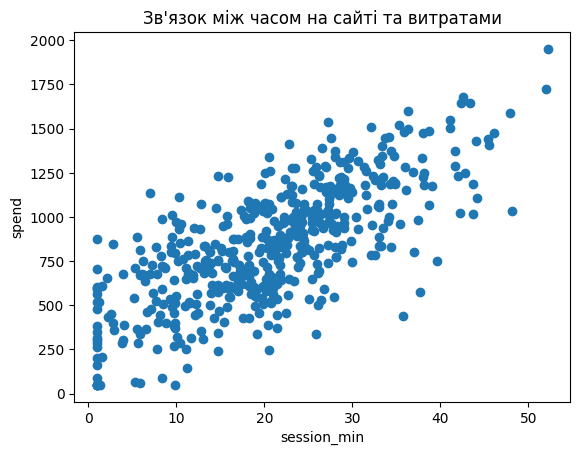

In [ ]:
# Завдання 12:

r, p_value = stats.pearsonr(df["session_min"], df["spend"])

print("Кореляція r:", r)
print("p-значення:", p_value)

plt.figure()
plt.scatter(df["session_min"], df["spend"])
plt.xlabel("session_min")
plt.ylabel("spend")
plt.title("Зв'язок між часом на сайті та витратами")
plt.show()


#### 💬 Інтерпретація 10

Опишіть звʼязок: він прямий чи зворотний? Сильний чи слабкий? Значущий? І найголовніше: чи можна стверджувати, що довший час на сайті СПРИЧИНЯЄ більші витрати? Поясніть свою думку.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Связь между временем на сайте (session_min) и расходами (spend) является прямой, сильной и статистически значимой.

Коэффициент корреляции r = 0.73 говорит о сильной положительной связи: чем больше времени пользователь проводит на сайте, тем выше его расходы.
p-value = 4.05, что намного меньше 0.05, подтверждает, что эта связь не случайна и является статистически значимой.

Несмотря на сильную и значимую корреляцию, нельзя утверждать, что большее время на сайте напрямую вызывает увеличение расходов.

Связь сильная, прямая и значимая, но причинно-следственный вывод делать нельзя.

**Сценарій:** чи повʼязаний вік клієнта (`age`) з його витратами (`spend`)?

#### ✏️ Завдання 13 (код)

Порахуйте кореляцію між `age` та `spend`.

In [ ]:
# Завдання 13:

r, p_value = stats.pearsonr(df["age"], df["spend"])

print("Кореляція r:", r)
print("p-значення:", p_value)


Кореляція r: -0.04181729618563376
p-значення: 0.35075231841402615


#### 💬 Інтерпретація 11

Що показала кореляція? Порівняйте цей результат із попереднім (час на сайті vs витрати). У якому випадку звʼязок сильніший і чому це важливо для бізнесу?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Корреляция между возрастом и расходами оказалась очень слабой и статистически незначимой (r = -0.04, p = 0.35). Это означает, что возраст практически не связан с тем, сколько клиент тратит.

Если сравнить с предыдущим результатом (время на сайте vs расходы), то там наблюдалась сильная положительная корреляция (r = 0.73, p = 0), которая была статистически значимой и указывала на выраженную связь между вовлечённостью пользователя и его расходами.

Это означает, что вовлечённость (время на сайте) является гораздо более важным фактором для прогнозирования расходов, чем возраст клиента. Поэтому бизнесу имеет смысл фокусироваться не на демографических характеристиках, а на поведении пользователей.

Сильный эффект наблюдается только у поведенческого показателя, а возраст как фактор ценности клиента в этой выборке практически не работае

---
# Розділ 7. 🔥 Велике завдання: A/B-тест

## 🟦 Теорія: A/B-тестування

Це головне застосування статистики в аналітиці. Ми порівнюємо дві версії (A — контроль, B — варіант) і перевіряємо, чи нова версія справді краща, чи різниця випадкова.

Оскільки результат тут — **категоріальний** (конвертувався / ні), ми використовуємо **хі-квадрат** на таблиці спряженості «група × конверсія».

**Дані `ab_test.csv`:**
- `session_id` — ID сесії
- `group` — A (стара версія) або B (нова версія)
- `converted` — 1 (купив) або 0 (не купив)

Це повноцінне завдання, що імітує реальну роботу аналітика. Виконуйте крок за кроком.

**Крок 1. Дослідіть дані.**

#### ✏️ Завдання 14 (код)

Подивіться на дані `ab`: скільки сесій у групі A і скільки в групі B? (підказка: `value_counts` на `group`)

In [ ]:
# Завдання 14:

print(ab["group"].value_counts())

group
A    4000
B    4000
Name: count, dtype: int64


**Крок 2. Порахуйте конверсію кожної групи.**

Конверсія = частка тих, хто купив = середнє значення стовпця `converted` (бо це 0 і 1).

#### ✏️ Завдання 15 (код)

Порахуйте конверсію (середнє `converted`) для групи A і для групи B окремо. (Підказка: `ab.groupby('group')['converted'].mean()`) На скільки відсоткових пунктів відрізняється конверсія?

In [ ]:
# Завдання 15:

conversion = ab.groupby("group")["converted"].mean()

print(conversion)

diff = (conversion["B"] - conversion["A"]) * 100

print("Різниця (B - A), у відсоткових пунктах:", diff)

group
A    0.101
B    0.119
Name: converted, dtype: float64
Різниця (B - A), у відсоткових пунктах: 1.799999999999999


#### 💬 Інтерпретація 12

Яка група показує вищу конверсію? Чи означає ця різниця в числах, що версія B точно краща? Чому ми НЕ можемо зробити висновок лише з цих чисел, без статистичного тесту?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Группа B показывает более высокую конверсию (11.9%) по сравнению с группой A (10.1%), разница составляет +1.8 процентных пункта.

Однако это не означает, что версия B точно лучше. Разница в процентах сама по себе не учитывает случайные колебания данных.

Почему нельзя делать вывод только по числам:
Любое A/B-тестирование основано на выборке пользователей, а не на всей генеральной совокупности. Поэтому наблюдаемая разница может:

возникнуть случайно,
быть нестабильной при повторном тесте,
исчезнуть при увеличении данных.

**Крок 3. Сформулюйте гіпотези.**

#### 💬 Інтерпретація 13

Запишіть нульову (H₀) та альтернативну (H₁) гіпотези для цього A/B-тесту своїми словами.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

H₀ (нулевая гипотеза):
Конверсия в группах A и B одинаковая. Это означает, что версия страницы (старая или новая) не влияет на вероятность покупки, и любые различия в конверсии являются случайными.

H₁ (альтернативная гипотеза):
Конверсия в группах A и B различается. Это означает, что версия страницы влияет на поведение пользователей и вероятность покупки, и наблюдаемая разница не случайна.

**Крок 4. Проведіть тест.**

#### ✏️ Завдання 16 (код)

Побудуйте таблицю спряженості `group` × `converted` і проведіть тест хі-квадрат. Виведіть таблицю та p-значення.

In [ ]:
# Завдання 16:

table = pd.crosstab(ab["group"], ab["converted"])
print(table)

chi2, p_value, dof, expected = stats.chi2_contingency(table)

print("Chi2-статистика:", chi2)
print("p-значення:", p_value)
print("Ступені свободи:", dof)
print("Очікувані частоти:\n", expected)

converted     0    1
group               
A          3596  404
B          3524  476
Chi2-статистика: 6.436414708886619
p-значення: 0.01118040771123417
Ступені свободи: 1
Очікувані частоти:
 [[3560.  440.]
 [3560.  440.]]


**Крок 5. Висновок.**

#### 💬 Інтерпретація 14

На основі p-значення: чи є різниця між версіями статистично значущою (при α = 0.05)? Який ваш висновок — впроваджувати версію B чи ні? Сформулюйте фінальну рекомендацію для продуктової команди одним абзацом, як справжній аналітик.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

При уровне значимости α = 0.05 разница между версиями A и B является статистически значимой, так как p-value = 0.011 < 0.05. Это означает, что наблюдаемое улучшение конверсии в группе B по сравнению с группой A с высокой вероятностью не является случайным.

На основе результатов A/B-теста можно рекомендовать внедрение версии B, так как она демонстрирует статистически значимое увеличение конверсии (примерно +1.8 процентных пункта). Это означает реальный положительный эффект новой версии на поведение пользователей, а не случайные колебания данных.

---
# Розділ 8. 🧠 Обери тест сам

## 🟦 Теорія

Найважливіша навичка аналітика — не запам'ятати функції, а вміти **обрати правильний тест** для задачі. У цьому розділі ми НЕ підказуємо тест — ви маєте визначити його самі.

**Алгоритм вибору:**
1. Який тип даних на виході? (числовий чи категоріальний)
2. Скільки груп / змінних порівнюємо?
3. Це незалежні групи чи «до/після» в тих самих об'єктів?

Кожне завдання: спочатку у клітинці інтерпретації **назвіть тест і поясніть вибір**, потім напишіть код.

**Задача A.** Компанія хоче знати, чи відрізняється середній вік клієнтів у трьох каналах залучення.

#### 💬 Інтерпретація 15

Який тест ви оберете і чому? (Спочатку відповідь, потім код нижче.)

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Для данной задачи я выбираю однофакторный дисперсионный анализ ANOVA.

Почему именно ANOVA:
зависимая переменная возраст числовая;
независимая переменная канал привлечения категориальная;
сравниваются три независимые группы Органика, Реклама, Соцсети;
нужно проверить, есть ли различия в среднем возрасте хотя бы между двумя группами.

ANOVA подходит лучше, чем множественные t-тесты, потому что позволяет одновременно сравнить все группы и избежать проблемы множественных сравнений.

#### ✏️ Завдання 17 (код)

Проведіть обраний тест для задачі A (вік за каналами).

In [2]:
# Завдання 17:

print(df.groupby("channel")["age"].mean())

organic = df[df["channel"] == "Органіка"]["age"]
ads = df[df["channel"] == "Реклама"]["age"]
social = df[df["channel"] == "Соцмережі"]["age"]

f_stat, p_value = stats.f_oneway(organic, ads, social)

print("F-статистика:", f_stat)
print("p-значение:", p_value)


channel
Органіка     34.350575
Реклама      35.427673
Соцмережі    34.209581
Name: age, dtype: float64
F-статистика: 0.5988514770608647
p-значение: 0.5498382919629132


#### 💬 Інтерпретація 16

Що показав результат? Сформулюйте висновок.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Результат ANOVA показал, что статистически значимых различий в возрасте клиентов между каналами привлечения не существует. Значение p-value = 0.55, что значительно больше 0.05, поэтому нулевая гипотеза не отвергается.

Канал привлечения не влияет на возраст клиентов — различия между средними значениями в группах Органика, Реклама и Соцсети являются случайными и не имеют статистической значимости.

**Задача B.** Маркетолог стверджує, що середні витрати клієнтів дорівнюють 900 грн.

#### 💬 Інтерпретація 17

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Для этой задачи подходит одновыборочный t-тест (One-sample t-test).

Я выбираю этот тест, потому что сравнивается среднее значение одной числовой выборки (расходы клиентов) с заранее заданным значением 900 грн. Цель теста определить, отличается ли средний расход клиентов от значения, которое предположил маркетолог.

#### ✏️ Завдання 18 (код)

Проведіть обраний тест для задачі B.

In [3]:
# Завдання 18:

mean_spend = df["spend"].mean()
print("Середні витрати:", mean_spend)

t_stat, p_value = stats.ttest_1samp(df["spend"], 900)

print("t-статистика:", t_stat)
print("p-значення:", p_value)


Середні витрати: 845.01634
t-статистика: -3.6870084642812735
p-значення: 0.00025179111192614583


#### 💬 Інтерпретація 18

Висновок: маркетолог має рацію?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Нет, маркетолог не прав. Результат одновыборочного t-теста показал, что средние расходы клиентов статистически значимо отличаются от 900 грн. Значение p-value = 0.00025, что меньше 0.05, поэтому мы отвергаем нулевую гипотезу. Фактические средние расходы составляют около 845 грн, то есть они значительно ниже заявленных 900 грн.

**Задача C.** Чи повʼязана країна клієнта (`country`) з пристроєм (`device`)?

#### 💬 Інтерпретація 19

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Для этой задачи подходит хи-квадрат тест независимости (χ² test of independence).

Я выбираю этот тест, потому что:

обе переменные (страна клиента и устройство) являются категориальными;
мы хотим проверить, есть ли связь между двумя категориальными признаками;
данные представлены в виде частот (количество наблюдений в каждой категории).

Хи-квадрат тест позволяет определить, являются ли переменные независимыми или между ними существует статистически значимая связь.

#### ✏️ Завдання 19 (код)

Проведіть обраний тест для задачі C.

In [4]:
# Завдання 19:

table = pd.crosstab(df["country"], df["device"])
print(table)

chi2, p_value, dof, expected = stats.chi2_contingency(table)

print("Chi2-статистика:", chi2)
print("p-значення:", p_value)
print("Ступені свободи:", dof)
print("Очікувані частоти:\n", expected)

device     Desktop  Mobile
country                   
Німеччина       46      63
Польща          49      82
Україна         94     166
Chi2-статистика: 1.2066541457059188
p-значення: 0.5469887339438565
Ступені свободи: 2
Очікувані частоти:
 [[ 41.202  67.798]
 [ 49.518  81.482]
 [ 98.28  161.72 ]]


#### 💬 Інтерпретація 20

Висновок про звʼязок країни та пристрою.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Результат χ²-теста показал, что между страной клиента и используемым устройством нет статистически значимой связи. Поскольку p-value = 0.547 > 0.05, мы не отвергаем нулевую гипотезу о независимости переменных.

Вывод:

Страна клиента не влияет на выбор устройства (Desktop или Mobile). Различия в распределении между странами можно считать случайными, поэтому сегментировать пользователей по стране с точки зрения устройства не имеет смысла.

**Задача D.** Чи повʼязаний вік клієнта з часом, який він проводить на сайті?

#### 💬 Інтерпретація 21

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Для этой задачи подходит корреляционный анализ (корреляция Пирсона).

Почему именно этот тест:
обе переменные (возраст клиента и время на сайте) — числовые;
мы хотим понять, есть ли линейная связь между ними;
нужно измерить силу и направление зависимости, а не сравнивать группы.

Корреляция Пирсона позволяет оценить, увеличивается ли время на сайте с возрастом или уменьшается, и насколько сильна эта связь.

#### ✏️ Завдання 20 (код)

Проведіть обраний тест для задачі D.

In [5]:
# Завдання 20:

r, p_value = stats.pearsonr(df["age"], df["session_min"])

print("Кореляція r:", r)
print("p-значення:", p_value)

Кореляція r: -0.011949542455704312
p-значення: 0.7898228650416101


#### 💬 Інтерпретація 22

Опишіть звʼязок (напрямок, сила, значущість).

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Связь между возрастом клиента и временем, проведённым на сайте, практически отсутствует. Коэффициент корреляции r = -0.012 указывает на очень слабую отрицательную зависимость, которая фактически стремится к нулю.

Значение p-value = 0.79 значительно больше 0.05, поэтому эта связь не является статистически значимой.

Направление связи формально отрицательное, но настолько слабое, что им можно пренебречь. На практике это означает, что возраст клиентов не влияет на время, проведённое на сайте, и любые наблюдаемые различия случайны.

---
# 🎉 Вітаємо із завершенням!

Ви пройшли повний цикл роботи аналітика зі статистичними тестами:

- ✅ Одновибірковий, двовибірковий та парний t-тести
- ✅ ANOVA для 3+ груп
- ✅ Хі-квадрат для категоріальних даних
- ✅ Кореляція для числових змінних
- ✅ Повноцінний A/B-тест
- ✅ Самостійний вибір тесту під задачу

## Головне, що варто винести

1. **Вибір тесту** важливіший за код. Завжди питайте: який тип даних? скільки груп? незалежні чи парні?
2. **p-значення** саме по собі — це лише число. Цінність створює ваша **інтерпретація**.
3. **Контекст вирішує:** памʼятайте про розмір ефекту, практичну значущість і те, що кореляція ≠ причинність.

## Питання для самоперевірки
- Чи можете ви пояснити різницю між парним і двовибірковим t-тестом?
- Чому не можна замінити одну ANOVA трьома t-тестами?
- Що означає «не відхилили H₀» — чи це те саме, що «довели, що ефекту немає»?

Якщо на всі три питання ви відповідаєте впевнено — ви добре засвоїли тему. Так тримати! 📊
